In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
df2 = pd.read_csv('uber_nyc_enriched.csv')
df2.shape

(29101, 13)

In [3]:
df2.columns.tolist()

['pickup_dt',
 'borough',
 'pickups',
 'spd',
 'vsb',
 'temp',
 'dewp',
 'slp',
 'pcp01',
 'pcp06',
 'pcp24',
 'sd',
 'hday']

In [5]:
print(df2.isnull().sum())
print(df2['pickup_dt'].min, df2['pickup_dt'].max())

pickup_dt       0
borough      3043
pickups         0
spd             0
vsb             0
temp            0
dewp            0
slp             0
pcp01           0
pcp06           0
pcp24           0
sd              0
hday            0
dtype: int64
<bound method Series.min of 0        2015-01-01 01:00:00
1        2015-01-01 01:00:00
2        2015-01-01 01:00:00
3        2015-01-01 01:00:00
4        2015-01-01 01:00:00
                ...         
29096    2015-06-30 23:00:00
29097    2015-06-30 23:00:00
29098    2015-06-30 23:00:00
29099    2015-06-30 23:00:00
29100    2015-06-30 23:00:00
Name: pickup_dt, Length: 29101, dtype: object> 2015-06-30 23:00:00


In [6]:
df2[df2['borough'].isnull()].head(10)

,pickup_dt,borough,pickups,spd,vsb,temp,dewp,slp,pcp01,pcp06,pcp24,sd,hday
6,2015-01-01 01:00:00,NaN,4,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y
13,2015-01-01 02:00:00,NaN,11,3.0,10.0,30.0,6.0,1023.0,0.0,0.0,0.0,0.0,Y
20,2015-01-01 03:00:00,NaN,1,5.0,10.0,30.0,8.0,1022.3,0.0,0.0,0.0,0.0,Y
27,2015-01-01 04:00:00,NaN,2,5.0,10.0,29.0,9.0,1022.0,0.0,0.0,0.0,0.0,Y
34,2015-01-01 05:00:00,NaN,3,5.0,10.0,28.0,9.0,1021.8,0.0,0.0,0.0,0.0,Y
65,2015-01-01 10:00:00,NaN,1,3.0,10.0,27.0,6.0,1020.2,0.0,0.0,0.0,0.0,Y
78,2015-01-01 12:00:00,NaN,1,3.0,10.0,27.0,7.0,1020.9,0.0,0.0,0.0,0.0,Y
85,2015-01-01 13:00:00,NaN,2,7.0,10.0,27.0,7.0,1021.2,0.0,0.0,0.0,0.0,Y
92,2015-01-01 14:00:00,NaN,2,0.0,10.0,28.0,6.0,1021.4,0.0,0.0,0.0,0.0,Y
99,2015-01-01 15:00:00,NaN,2,6.0,10.0,30.0,6.0,1021.9,0.0,0.0,0.0,0.0,Y


In [7]:
df2[df2['borough'].isnull()]['hday'].value_counts()

,count
hday,
N,2924
Y,119


In [8]:
df2[df2['borough'].isnull()]['pickups'].describe()

,pickups
count,3043.000000
mean,2.057180
std,1.330625
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,11.000000


In [9]:
df2['pickups'].describe()

,pickups
count,29101.000000
mean,490.215903
std,995.649536
min,0.000000
25%,1.000000
50%,54.000000
75%,449.000000
max,7883.000000


In [10]:
df2_clean = df2.dropna(subset=['borough'])
df2_clean.shape

(26058, 13)

In [11]:
df2_clean.duplicated().sum()

np.int64(0)

In [12]:
df2_clean[['pickups', 'temp', 'spd', 'pcp24']].describe()

,pickups,temp,spd,pcp24
count,26058.000000,26058.000000,26058.000000,26058.000000
mean,547.222082,47.489005,6.000039,0.091036
std,1037.307748,19.772156,3.706328,0.220435
min,0.000000,2.000000,0.000000,0.000000
25%,1.000000,31.500000,3.000000,0.000000
50%,86.000000,45.000000,6.000000,0.000000
75%,506.000000,64.000000,8.000000,0.051667
max,7883.000000,89.000000,21.000000,2.100000


In [13]:
df2_clean['borough'].value_counts()

,count
borough,
Bronx,4343
Brooklyn,4343
EWR,4343
Manhattan,4343
Queens,4343
Staten Island,4343


In [14]:
df2_clean.groupby('borough')['pickups'].mean().sort_values(ascending=False)

,pickups
borough,
Manhattan,2387.253281
Brooklyn,534.431269
Queens,309.354824
Bronx,50.667050
Staten Island,1.601888
EWR,0.024177


/tmp/ipykernel_949/2072137845.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2_clean['temp_range'] = pd.cut(df2_clean['temp'],
/tmp/ipykernel_949/2072137845.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_pickups_by_temp = df2_clean.groupby('temp_range')['pickups'].mean()


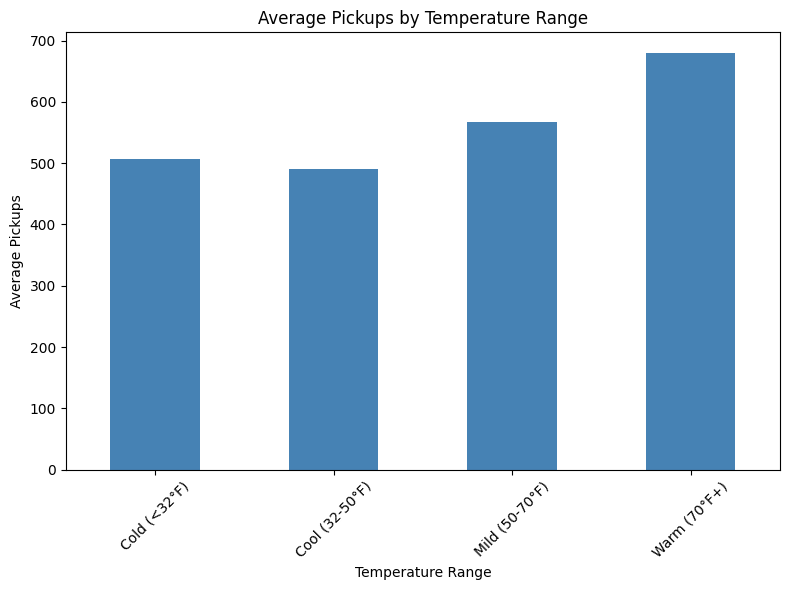

In [15]:
import matplotlib.pyplot as plt

df2_clean['temp_range'] = pd.cut(df2_clean['temp'],
                                    bins=[0, 32, 50, 70, 100],
                                    labels=['Cold (<32°F)', 'Cool (32-50°F)', 'Mild (50-70°F)', 'Warm (70°F+)'])

avg_pickups_by_temp = df2_clean.groupby('temp_range')['pickups'].mean()

plt.figure(figsize=(8,6))
avg_pickups_by_temp.plot(kind='bar', color='steelblue')
plt.title('Average Pickups by Temperature Range')
plt.xlabel('Temperature Range')
plt.ylabel('Average Pickups')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

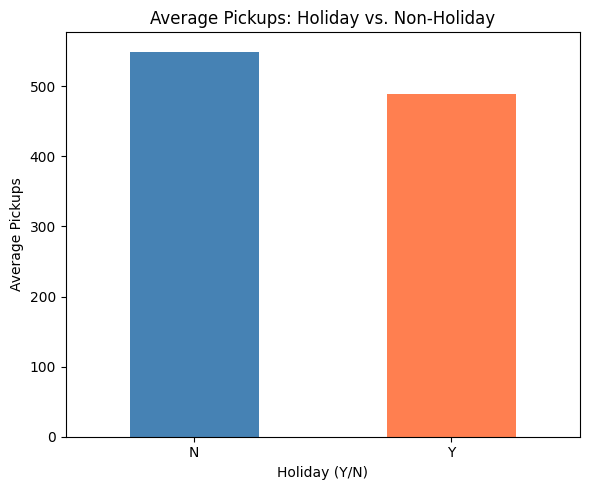

In [16]:
avg_pickups_by_holiday = df2_clean.groupby('hday')['pickups'].mean()

plt.figure(figsize=(6,5))
avg_pickups_by_holiday.plot(kind='bar', color=['steelblue', 'coral'])
plt.title('Average Pickups: Holiday vs. Non-Holiday')
plt.xlabel('Holiday (Y/N)')
plt.ylabel('Average Pickups')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
temp_borough = df2_clean.groupby(['borough', 'temp_range'])['pickups'].mean().unstack()
temp_borough

/tmp/ipykernel_949/972464164.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_borough = df2_clean.groupby(['borough', 'temp_range'])['pickups'].mean().unstack()


temp_range,Cold (<32°F),Cool (32-50°F),Mild (50-70°F),Warm (70°F+)
borough,,,,
Bronx,38.465278,40.717427,59.607396,72.215318
Brooklyn,451.993924,472.342020,586.586939,686.054913
EWR,0.019965,0.014658,0.032258,0.033237
Manhattan,2299.034722,2157.500000,2410.403619,2899.306358
Queens,245.770833,275.521173,340.896145,417.313584
Staten Island,1.259549,1.307003,1.804878,2.322254


/tmp/ipykernel_949/940673405.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2_clean['precip_flag'] = df2_clean['pcp24'].apply(lambda x: 'Rain/Snow' if x > 0 else 'No Precipitation')


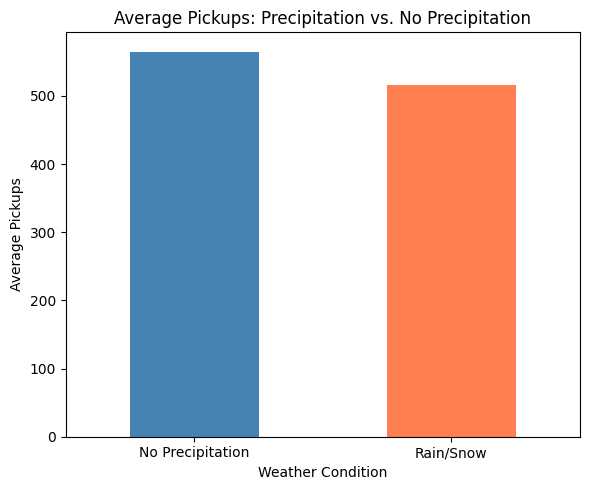

In [18]:
df2_clean['precip_flag'] = df2_clean['pcp24'].apply(lambda x: 'Rain/Snow' if x > 0 else 'No Precipitation')

avg_pickups_by_precip = df2_clean.groupby('precip_flag')['pickups'].mean()

plt.figure(figsize=(6,5))
avg_pickups_by_precip.plot(kind='bar', color=['steelblue', 'coral'])
plt.title('Average Pickups: Precipitation vs. No Precipitation')
plt.xlabel('Weather Condition')
plt.ylabel('Average Pickups')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()